DATASET DESCRIPTION:

The Telco Customer Churn dataset contains information about customers of a fictional telecommunications company.The main objective is to predict whether a customer is likely to leave (churn) the telecom company based on their demographic information, subscribed services, contract details, and billing information.

Target Variable : Churn (with the categories yes/no)
The dataset has substantially more non-churned customers than churned customers, making class imbalance analysis relevant for our project.

There are 20 input features covering demographic information , account information and services used by the customer.

Dimension of the dataset: 7043 rows × 21 columns.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("../data/TelcoCustomerChurn.csv")

The dataset is loaded from csv file into dataframe

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [13]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Though it shows that there are no null values but there are null values present in the form of NaN which are handled during preprocessing

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:

df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

EDA Visualizations

Distribution of Numerical features

In [14]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Features:")
print(numerical_cols.tolist())

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


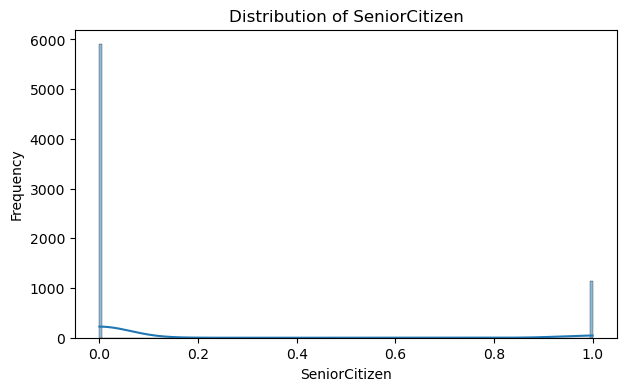

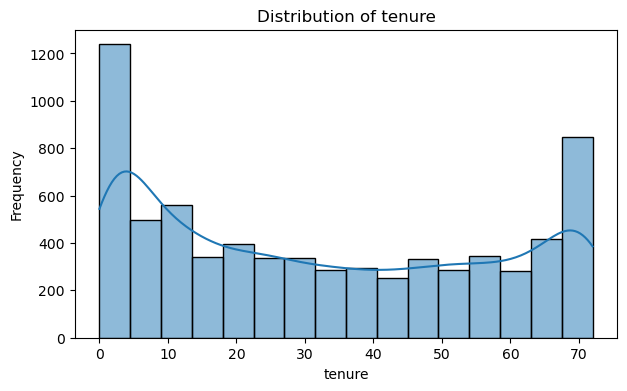

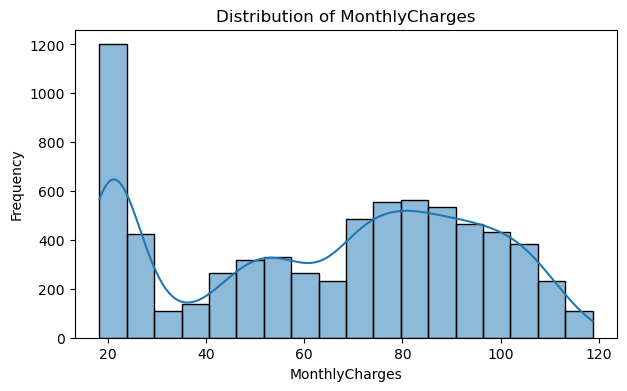

In [15]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Categorical Features

In [16]:
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Features:")
print(categorical_cols.tolist())

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


Drop customerID because its just an identifier which doesnt provide any useful information

In [17]:
categorical_cols = categorical_cols.drop('customerID')

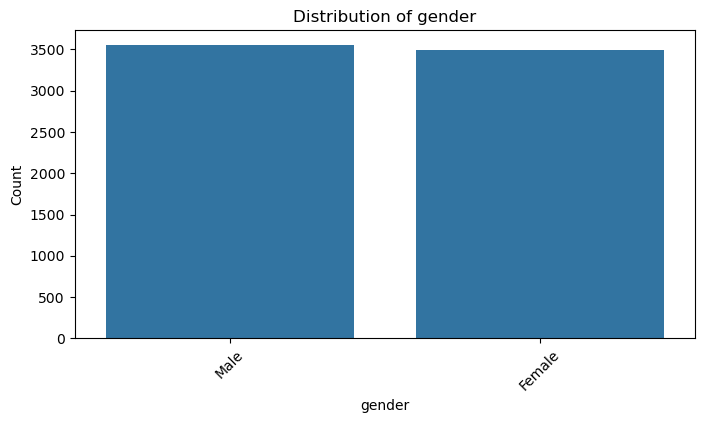

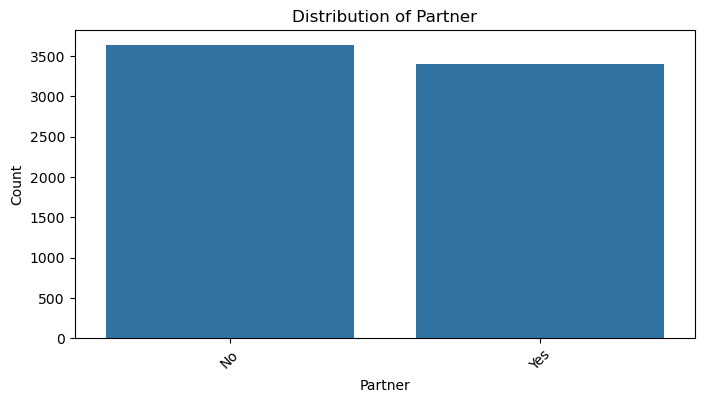

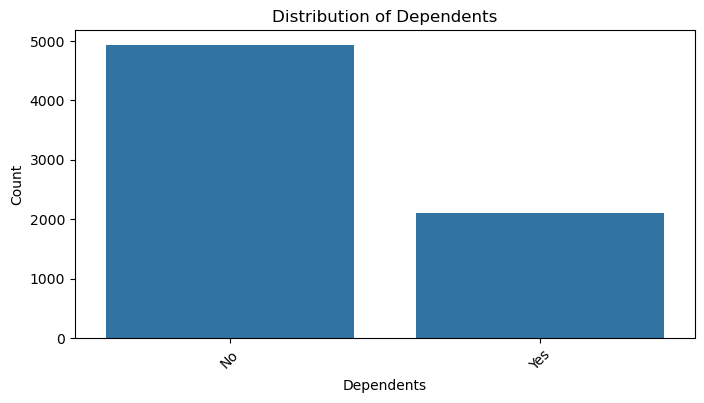

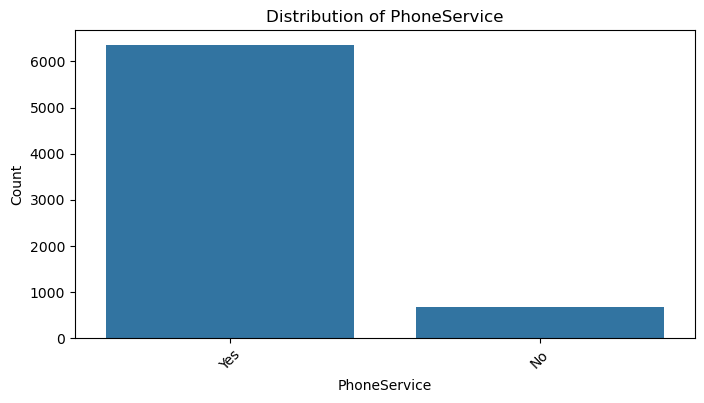

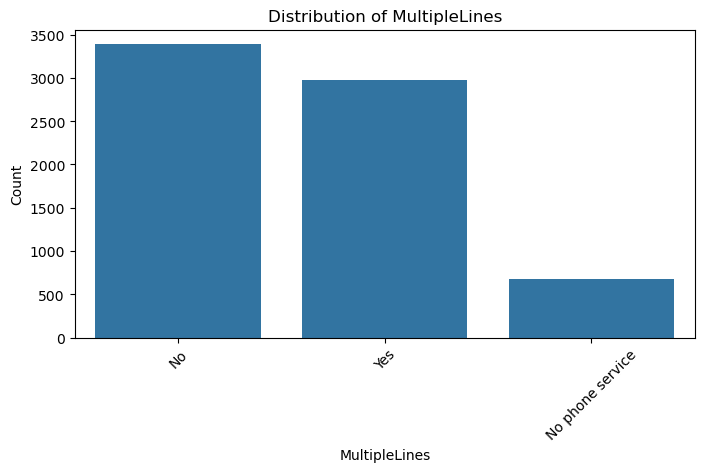

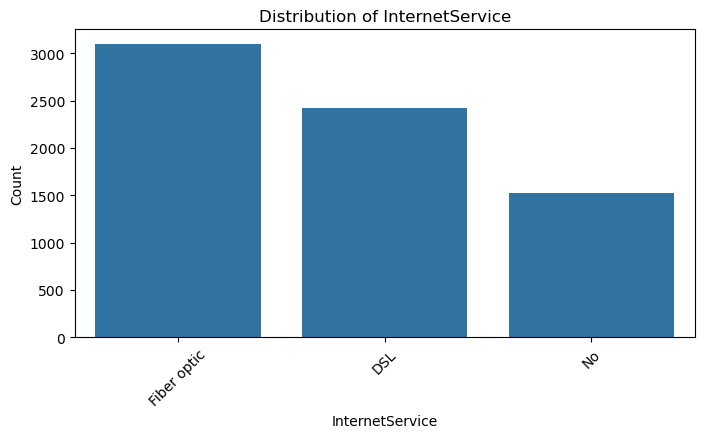

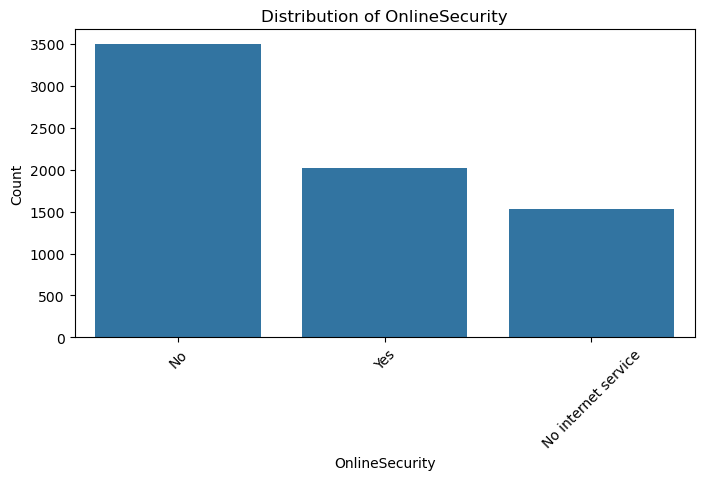

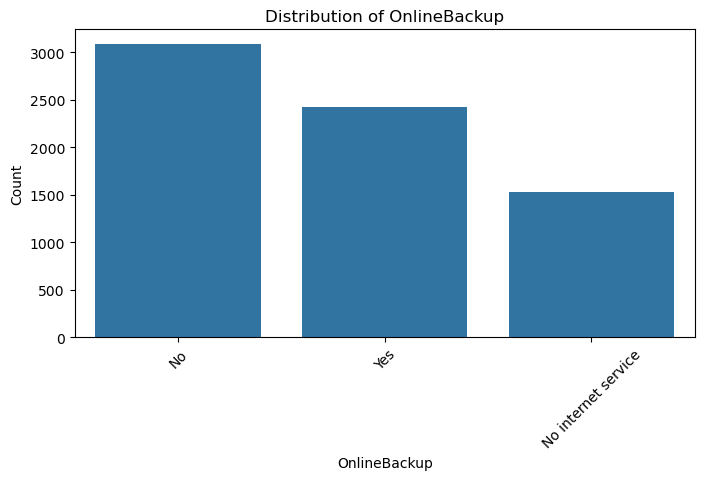

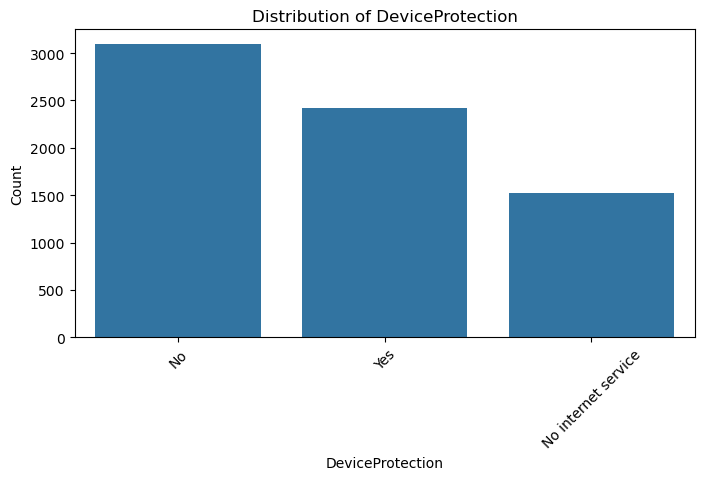

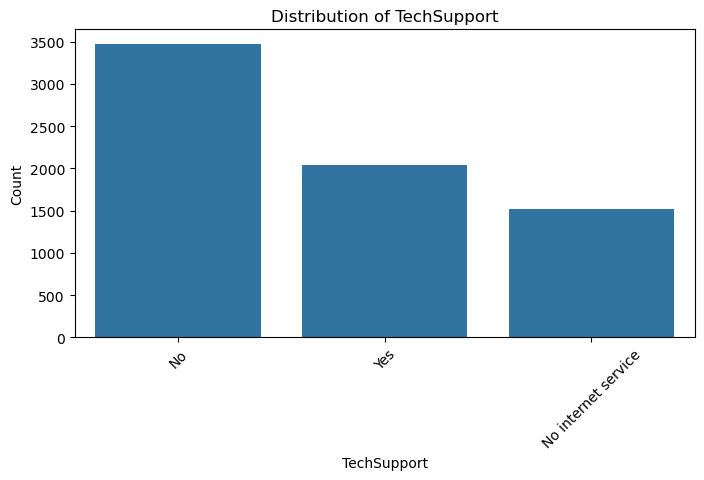

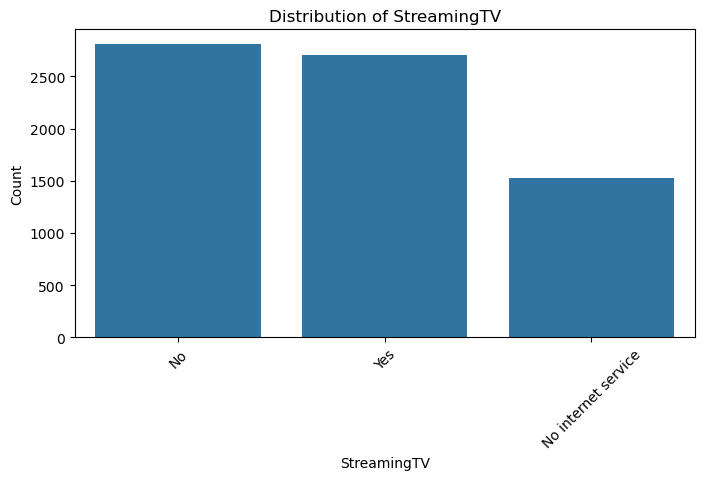

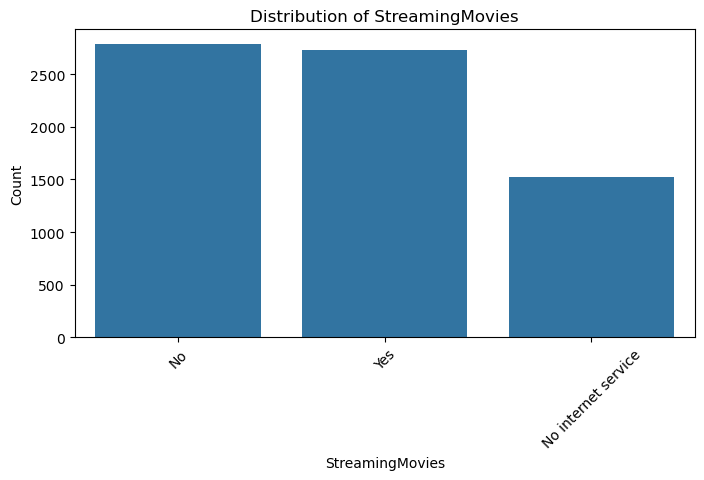

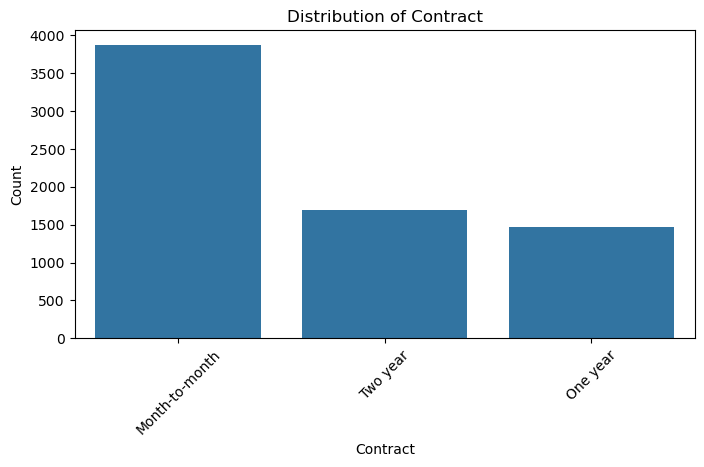

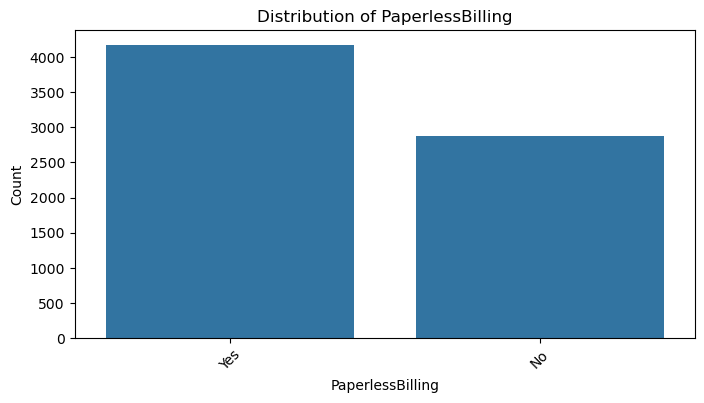

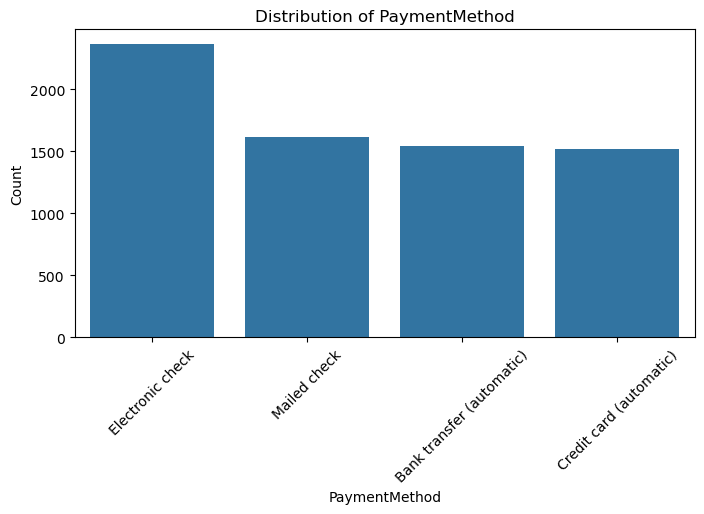

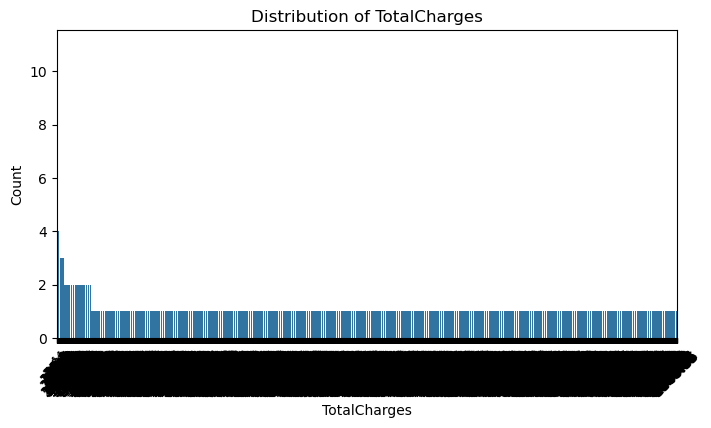

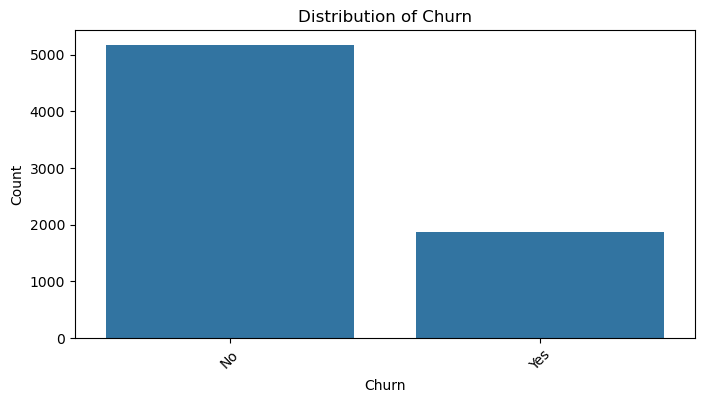

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

Distribution of target variable

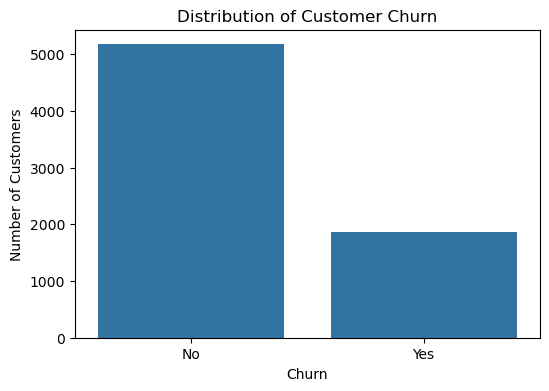

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Churn')

plt.title('Distribution of Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

Observation: The target variable is imbalanced, with a higher proportion of customers who did not churn compared to customers who churned. Therefore, accuracy alone may not be sufficient for evaluating the classification models. Precision, Recall, F1-score and ROC-AUC will also be considered.

Correlation HeatMap

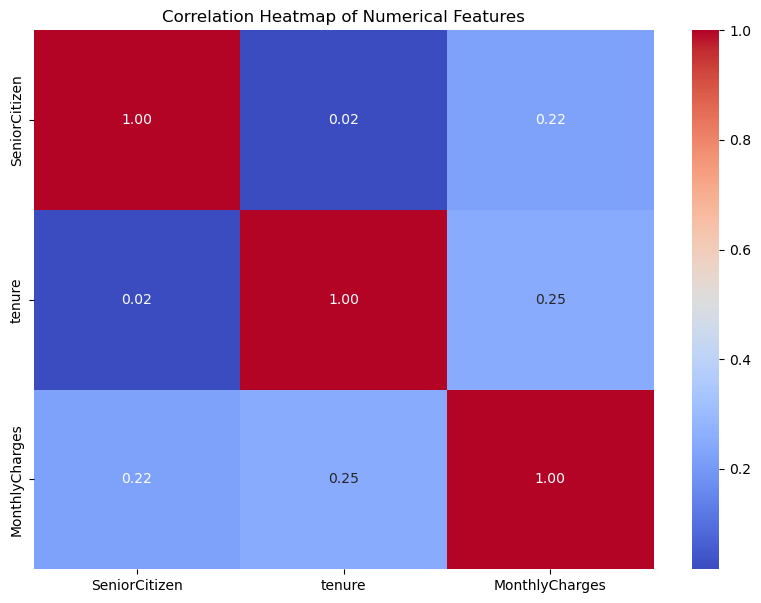

In [20]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

1)The heatmap shows a strong positive correlation between tenure and TotalCharges, since customers who stay longer generally accumulate higher total charges.

2)MonthlyCharges also has a positive relationship with TotalCharges, while the correlation between tenure and MonthlyCharges is relatively weak.These relationships are expected because TotalCharges depends largely on the duration of service and the monthly amount paid.

Feature-Target RelationShip 

1)Tenure vs Churn

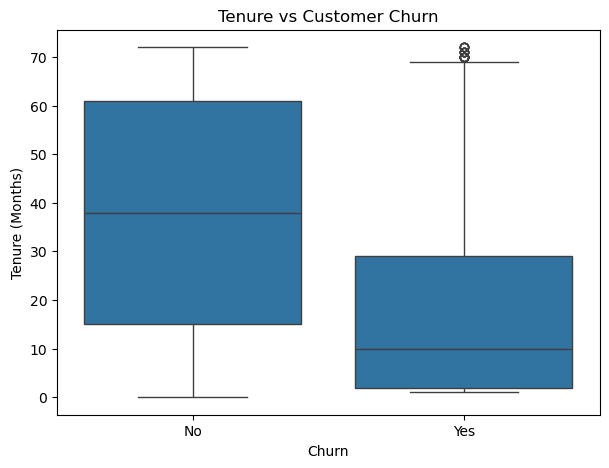

In [21]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='Churn', y='tenure')

plt.title('Tenure vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

Customers who churn generally have lower tenure than customers who stay, indicating that newer customers are more prone to churn

2)Monthly Charges vs Churn


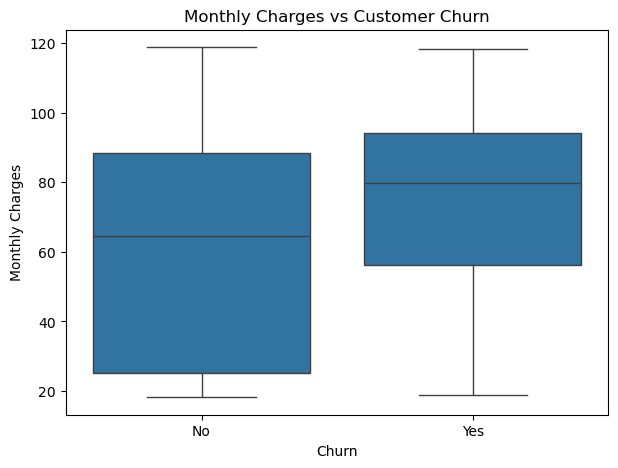

In [22]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

plt.title('Monthly Charges vs Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

Churned customers generally show higher monthly charges, suggesting that monthly cost may be associated with churn.